## Multicellular Factor Analysis with guided variables at the sample level

---
**NOTE**  
This is an advanced user notebook. Familiarity with MOFA-based multicellular factor analysis is assumed.

---

In some analyses, part of the variation across samples is already known and explicitly measured (e.g. batch, tissue compartment, disease state). Standard factor models may rediscover these effects as dominant latent factors, making interpretation less efficient.

To address this, **guided factor models** incorporate sample-level covariates directly into the factorization, resulting in a **semi-supervised decomposition**. This approach, introduced in [Capraz et al., 2024](https://www.biorxiv.org/content/10.1101/2024.10.10.617527v4.full), separates:

- **Guided factors**: latent factors explicitly associated with known covariates  
- **Unguided factors**: latent factors capturing remaining, potentially novel sources of variation  

By assigning specific factors to known variables during training, the model ensures that these sources of variation are captured explicitly, while leaving the remaining factors free to explain unexplained structure in the data.

---

### Why use guided factors?

Guided models are particularly useful when:
- known covariates dominate the variance structure  
- these covariates act as **confounders**  
- the goal is to uncover **novel biological programs beyond known effects**

In this setting, guided factors can be interpreted as **controlled axes of variation**, allowing cleaner interpretation of the remaining latent space.

Other applications:
- known covariates should affect the variance structure but because of sample size they may not be recovered (e.g. sex)

---

### Application to Crohn’s disease data

To illustrate the use of guided models, we apply MINA to a Crohn’s disease dataset. Crohn’s disease is a chronic inflammatory disorder of the gastrointestinal tract, characterized by patchy, transmural inflammation.

Here we re-analyse epithelial cells from the [scIBD atlas](https://www.nature.com/articles/s41586-025-09907-x), focusing on ileal biopsies from [Kong et al., 2023](https://www.sciencedirect.com/science/article/pii/S1074761323000122?via%3Dihub).

In previous analyses, we observed that the **enriched tissue fraction** (e.g. epithelial vs lamina propria) is a major driver of variation across samples. This effect can obscure disease-related multicellular programs.

Here, we incorporate this information as a guiding variable, so that:
- one or more factors explicitly capture variation driven by tissue compartment  
- remaining factors are less confounded and better reflect **disease-associated multicellular programs**

This enables a more targeted exploration of epithelial variation across patients and conditions.

---


In [1]:
import mina
import scanpy as sc
import scanpy.external as sce
import numpy as np
import decoupler as dc
import math
import mofaflex as mf
import mudata as md
import pandas as pd
import matplotlib.pyplot as plt

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



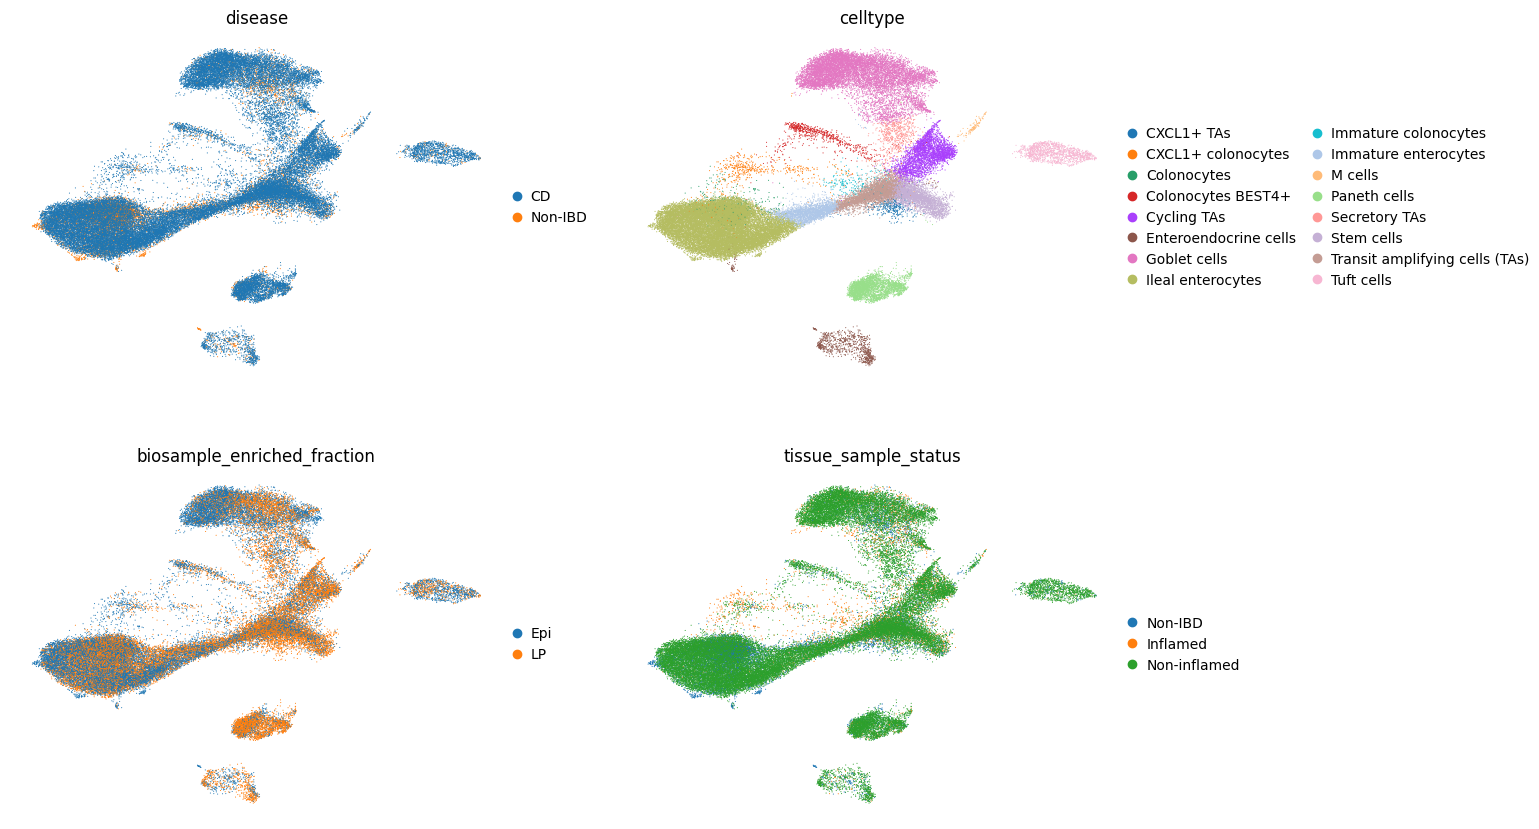

In [2]:
adata = sc.read_h5ad("./data/scIBD/KongEpi_adata_ref.h5ad")
adata = adata[adata.obs["organ"] == "Ileum", :].copy()
sc.pl.umap(adata, color=["disease", 'celltype', "biosample_enriched_fraction", "tissue_sample_status"], frameon=False, ncols=2)

### Processing the AnnData and preparing it for model fitting

In the previous tutorial, we described how to structure AnnData objects for multicellular factor analysis. As this notebook focuses on guided modeling, those preprocessing steps are not repeated here. Users are expected to follow the introductory tutorial for details on data preparation.

In [3]:
# We extract the metadata based on our column that is the reference
# Filter adata to only include ileum
# Process adata_raw
metadata = mina.up.extract_metadata_from_obs(obs=adata.obs, groupby="biosample_id", sort=False)
pdata = dc.pp.pseudobulk(adata, sample_col="biosample_id", groups_col="celltype")
# Manipulations on pdata
pdata.obs = pdata.obs.set_index("biosample_id", drop=False)
pdata.obs.index.name = None

# Make list of adatas per pseudobulk cell type
anndata_dict = mina.up.split_anndata_by_celltype(pdata=pdata, grouping="celltype")

# Adding gene expression total counts - TODO add to upstream as a function
for _cell_type, adata_raw in anndata_dict.items():
    # Sum across observations (rows) for each gene (column)
    if hasattr(adata_raw.X, "toarray"):
        # Sparse matrix case
        total_counts = adata_raw.X.sum(axis=0).A1  # returns 1D array
    else:
        total_counts = adata_raw.X.sum(axis=0)  # numpy array

    # Add to .var
    adata_raw.var["total_counts"] = total_counts

# Making filters
mina.up.filter_anndata_by_ncells(anndata_dict, min_cells=20)
# From all the possible samples, let's ask for at least 40%
n_samples = len(metadata.index)
min_samples = math.trunc(n_samples * 0.4)
mina.up.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mina.up.filter_genes_byexpr(anndata_dict, min_count=20, min_prop=0.4)
mina.up.filter_views_by_genes(anndata_dict, min_genes_per_view=100)
mina.up.filter_samples_by_coverage(anndata_dict, threshold=0, min_prop=0.90)
mina.up.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mina.up.save_raw_counts(anndata_dict, layer_name="raw_counts")
mina.up.norm_log(anndata_dict, target_sum=1e6, exclude_highly_expressed=False, max_value=None, center=True)
mina.up.filter_hvgs(anndata_dict, groupby = None, ngroups_cut = None)
mina.up.filter_smpls_by_nview(anndata_dict, min_views = 5)

# Model data preparation
mina.up.utils.append_view_to_var(anndata_dict)
model_data = md.MuData(anndata_dict)

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:795: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['H101694_E', 'H101694_L', 'H102141_E', 'H102141_L', 'H110216_E']

    Inferred to be: categorical



Raw counts saved in the 'raw_counts' layer for each AnnData object.
Normalization, log-transformation, and scaling complete for all AnnData objects with target_sum = 1000000.0.


/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


### Fitting the model with MOFA-FLEX

Here, we use MOFA-FLEX to incorporate a sample-level covariate (`biosample_enriched_fraction`) as a guiding variable. This specifies that one latent factor should capture variation associated with this covariate, rather than allowing the model to rediscover it in an unguided manner.

As a result, the model is configured with:
- **1 guided factor** aligned with `biosample_enriched_fraction`  
- **4 unguided factors** capturing the remaining variation  

This does not “regress out” the covariate beforehand. Instead, the model **explicitly allocates part of the latent space** to explain this known source of variation during training.

---

Guided modeling requires specifying two additional components:

- `keys_dict`: defines which covariates are used to guide specific factors  
- `likelihood_dict`: defines the likelihood model for each guiding variable  

In this example, `biosample_enriched_fraction` is binary, so we use a **Bernoulli likelihood**. Other useful options are `Normal` for continuous covariates.

Multiple covariates can be included by extending these list and dictionary.

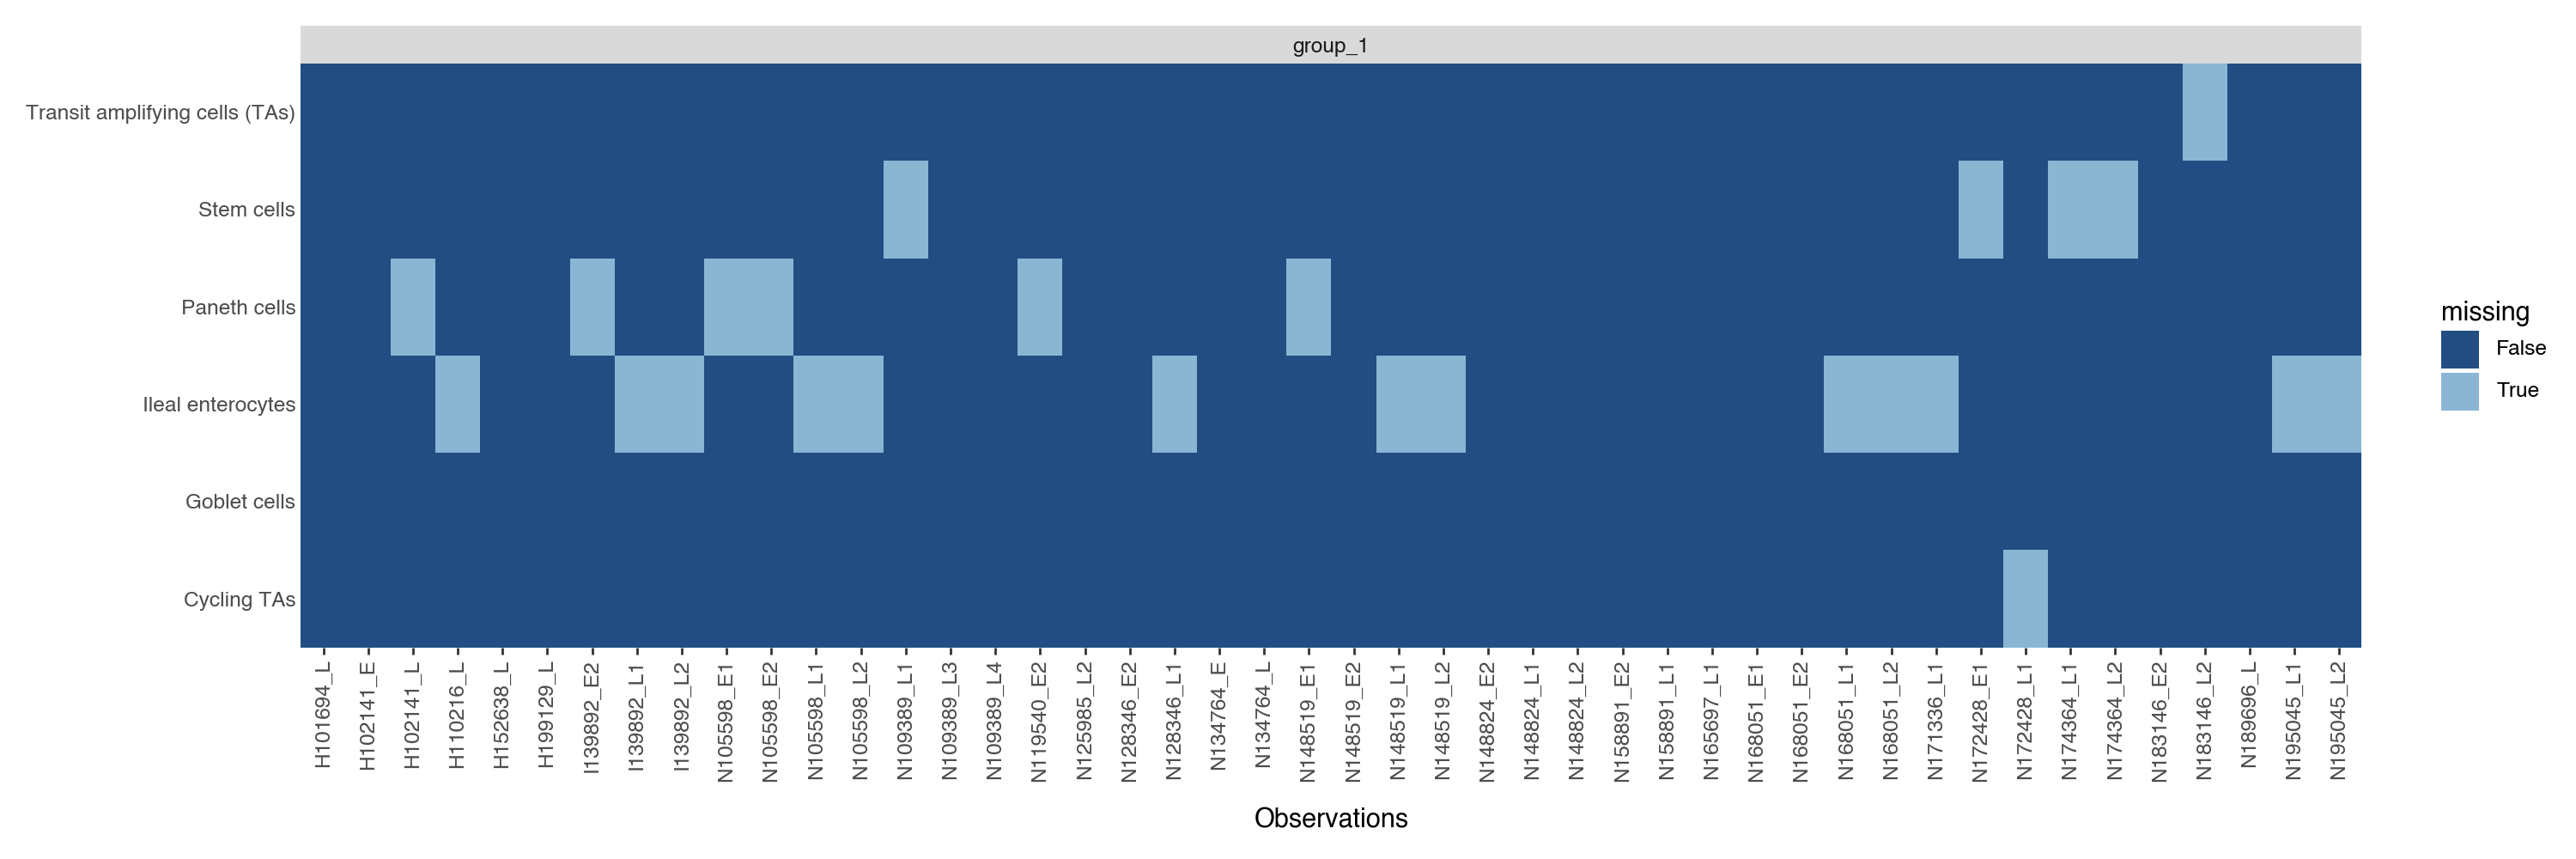

2026-03-27 13:45:35 | [WARNING] Could not import dask. Data arrays may be copied, resulting in high memory usage.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/an

In [4]:
seed_SOFA_FLEX = 42

# This guides the model
keys_dict = ["biosample_enriched_fraction"]
likelihood_dict = {"biosample_enriched_fraction": "Bernoulli"}

model = mf.MOFAFLEX(
    model_data,
    mf.DataOptions(guiding_vars_obs_keys=keys_dict),
    mf.ModelOptions(
        n_factors=4,
        weight_prior="Horseshoe",
        likelihoods="Normal",
        guiding_vars_likelihoods=likelihood_dict,
        annotation_confidence=0.995,
        init_factors="random",
    ),
    mf.TrainingOptions(  # batch_size = 20000,
        max_epochs=30000, device="cpu", seed=seed_SOFA_FLEX, save_path=False, lr=0.01, early_stopper_patience=500
    ),
)

### Outputs of a factor model

A factor model decomposes the data into **latent factors** (capturing sample-level variation) and **loadings** (capturing feature-level contributions), summarizing the main sources of variability.

This is unchanged from the basic workflow. Guided models produce the same outputs (factor scores, explained variance, and loadings), so all downstream functions in MINA can be applied in the same way.

In [26]:
amodel = mina.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=model,
)

The major difference is that in .var we have information of explained variance per group

In [29]:
amodel.var

,Cycling TAs:group_1,Goblet cells:group_1,Ileal enterocytes:group_1,Paneth cells:group_1,Stem cells:group_1,Transit amplifying cells (TAs):group_1
Factor1,0.068985,0.197131,0.120833,0.024169,0.045549,0.061334
Factor2,0.071068,0.064467,0.058174,0.079516,0.093251,0.068227
Factor3,0.131869,0.069033,0.107688,0.064303,0.093397,0.077810
Factor4,0.137038,0.067047,0.131774,0.057361,0.163901,0.184305
Factorbiosample_enriched_fraction,0.135966,0.078394,0.029174,0.118716,0.131408,0.090221


### Explore the variability used for guiding the model

We first test whether the learned factors are associated with `biosample_enriched_fraction`, which distinguishes lamina propria-enriched from epithelial-enriched biopsies.

In [7]:
fraction_stats = mina.down.get_associations(amodel, 
                           test_variable = "biosample_enriched_fraction",
                           test_type="categorical")

print(fraction_stats)

                             feature  statistic       p_value   adj_p_value
0                            Factor1   0.384801  5.382448e-01  5.382448e-01
1                            Factor2   1.128899  2.938071e-01  4.896785e-01
2                            Factor3   0.522781  4.734837e-01  5.382448e-01
3                            Factor4  12.350949  1.034058e-03  2.585144e-03
4  Factorbiosample_enriched_fraction  45.390030  2.778288e-08  1.389144e-07


As expected we see that `Factorbiosample_enriched_fraction` is the one most associated with the biosample_enriched_fraction, which is the variable we used to guide the model. We can also see that factor 4 is associated with it, but to a lesser extent. The other three factors are not significantly associated with the biosample_enriched_fraction.

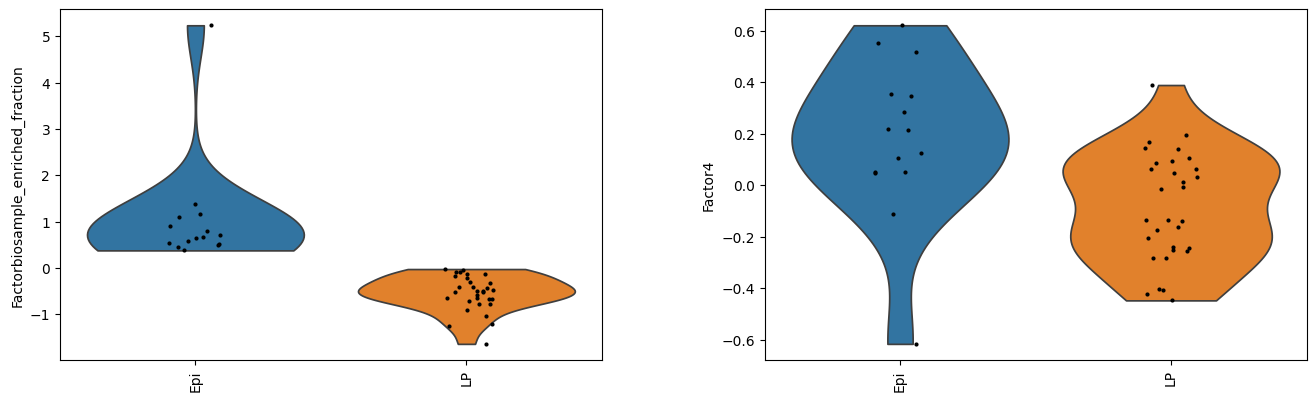

In [8]:
sc.pl.violin(amodel, 
             ["Factorbiosample_enriched_fraction","Factor4"], 
             groupby="biosample_enriched_fraction", rotation=90,size = 3)

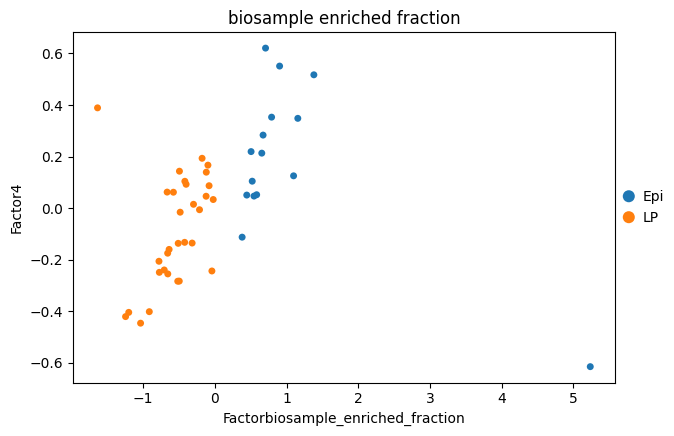

In [9]:
sc.pl.scatter(amodel,
              x = "Factorbiosample_enriched_fraction",
              y = "Factor4", 
              color  = "biosample_enriched_fraction", 
              size =100)

### Interpreting the model

The goal of guided modeling is not to enforce separation of samples according to predefined groups, but to assess whether the guiding variable explains a meaningful portion of the observed variability.

In practice, this requires evaluating whether the guided factor captures non-negligible variance. Guided factors that explain little or no variance indicate that the covariate is not strongly associated with the structure of the data and should not be overinterpreted.

Interpretation should therefore focus on:
- whether the guided factor explains substantial variance  
- how it relates to sample-level patterns  
- how unguided factors capture additional, independent sources of variation

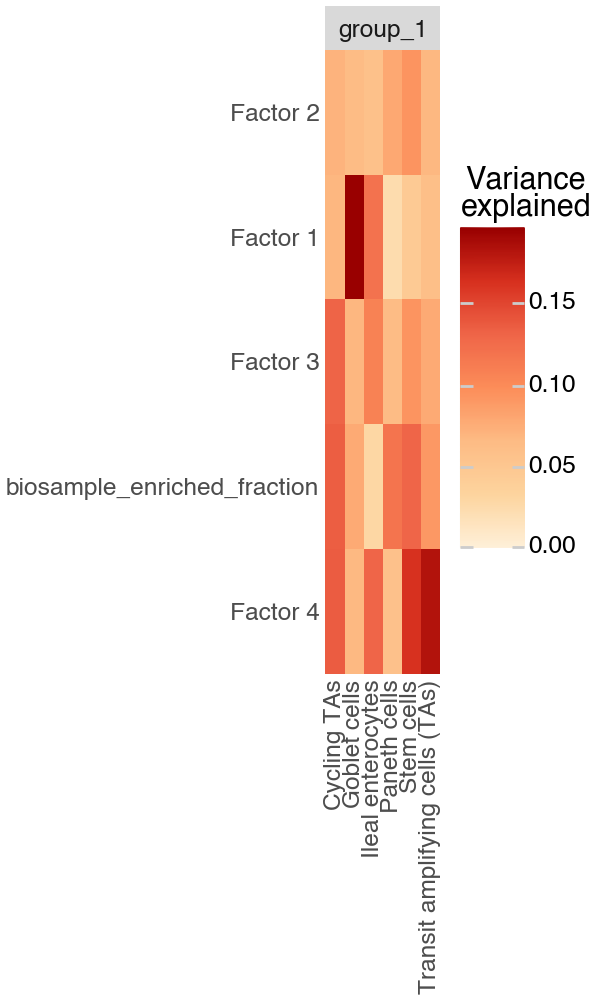

In [10]:
mf.pl.variance_explained(model)

In this case, the guiding variable captures a substantial portion of the variability across cell types. A similar pattern is also recovered by an unguided factor, suggesting that this source of variation manifests through partially distinct modes of multicellular coordination.

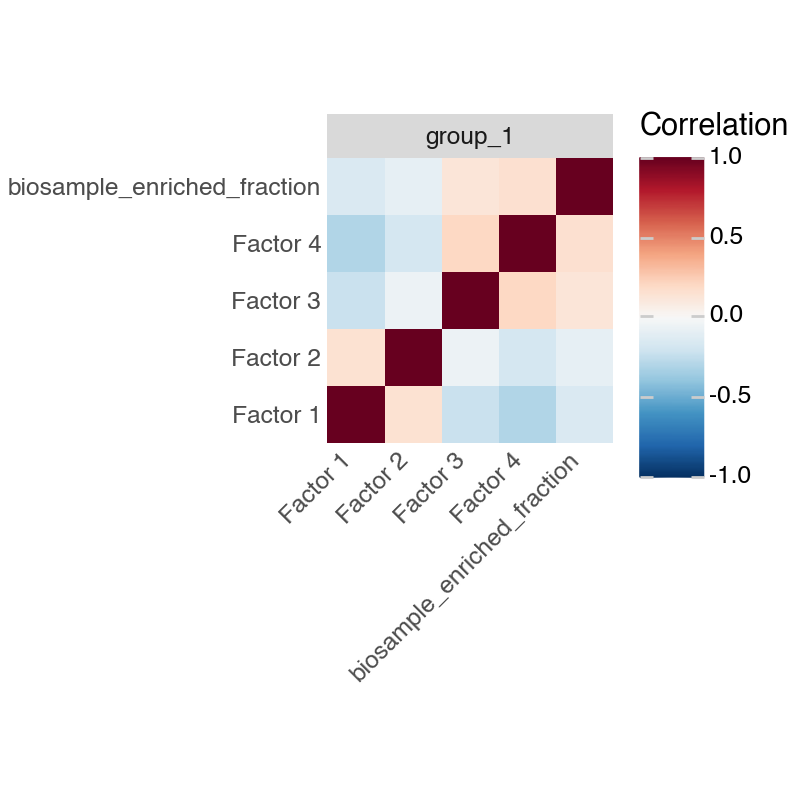

In [12]:
mf.pl.factor_correlation(model,figsize=(4,4))

In addition, we provide functions to analyse multiple variables simultaneously 

### Association of factors with disease

We will now test if there's an association between factor scores and disease group.

In [15]:
disease_stats = mina.down.get_associations(amodel, 
                           test_variable = "disease",
                           test_type="categorical",
                           random_effect = None)

print(disease_stats)

                             feature  statistic   p_value  adj_p_value
0                            Factor1   1.697776  0.199357     0.477075
1                            Factor2   0.799104  0.376225     0.477075
2                            Factor3   0.413437  0.523567     0.523567
3                            Factor4   9.928875  0.002925     0.014626
4  Factorbiosample_enriched_fraction   0.780930  0.381660     0.477075


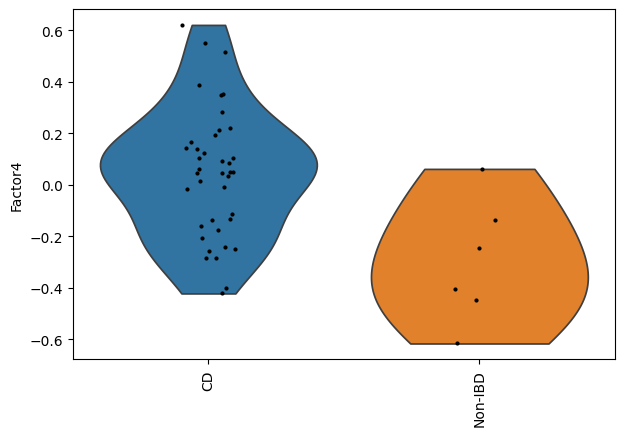

In [19]:
sc.pl.violin(amodel, 
             ["Factor4"], 
             groupby="disease", rotation=90,size = 3)

We observe that higher values of Factor 4 associate with Crohn's disease patients

### Projection of external datasets

Multicellular programs learned from one dataset can be used as a reference to project new datasets into the same latent space. This is particularly useful when the new dataset is too small to support joint model training (as described in later tutorials).

Projection is performed using the pseudoinverse of the gene loadings, which is multiplied by the observed gene expression matrix to infer factor scores for new samples.

MINA provides utility functions to perform this projection.

In the Crohn’s disease example, the guided model was trained on a single library preparation protocol; here, we project the remaining data into the learned latent space.

Projected data should contain overlapping cell types and represent comparable biological contexts to the reference dataset. While partial overlap is sufficient, missing genes or cell types may affect the quality and interpretability of the projection.

### Why project?

Projections are particularly useful when:
- you want to quickly compare if datasets share similar axes of variability (e.g. disease signal)
- you want to establish trajectories of tissue remodeling (e.g. when assesing the impact of perturbations)

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:795: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['H106265_N', 'H139073_N', 'H158108_N1', 'H158108_N2', 'H158108_N3']

    Inferred to be: categorical



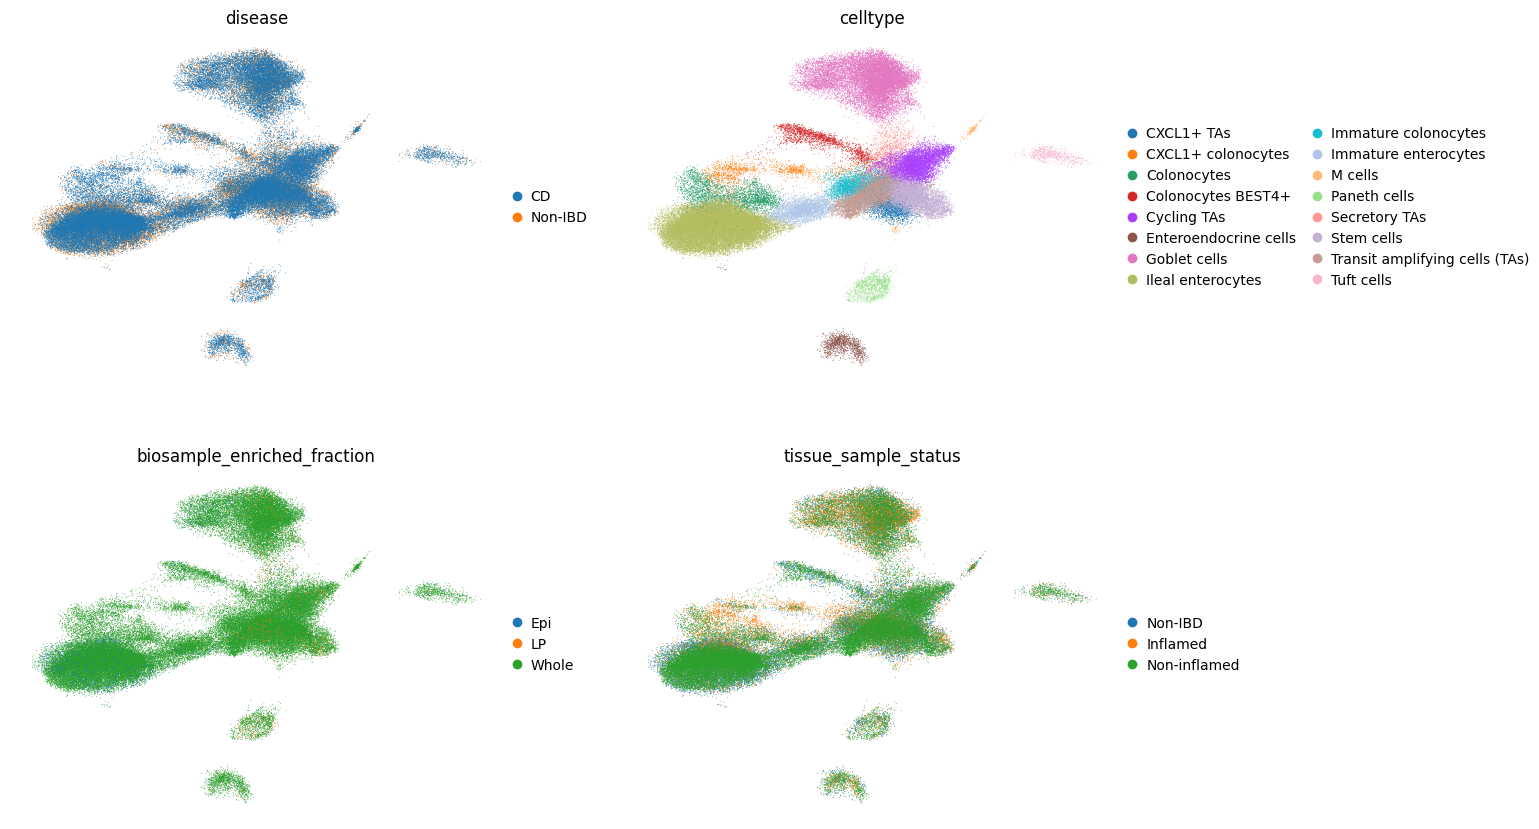

In [21]:
adata_proj = sc.read_h5ad("./data/scIBD/KongEpi_adata_proj.h5ad")
# Process adata_raw
metadata_proj = mina.up.extract_metadata_from_obs(obs=adata_proj.obs, groupby="biosample_id", sort=False)
pdata_proj = dc.pp.pseudobulk(adata_proj, sample_col="biosample_id", groups_col="celltype")
# Manipulations on pdata
pdata_proj.obs = pdata_proj.obs.set_index("biosample_id", drop=False)
pdata_proj.obs.index.name = None
sc.pl.umap(adata_proj, color=["disease", 'celltype', "biosample_enriched_fraction", "tissue_sample_status"], frameon=False, ncols=2)

### Preparing projected data

The only requirement for the projected data is to be in a multiview data structure (dictionary of anndatas). We use MINA's functions for this

In [22]:
anndata_dict_proj = mina.up.split_anndata_by_celltype(pdata=pdata_proj, grouping="celltype")

# Adding gene expression total counts - TODO add to upstream as a function
for _cell_type, adata_raw in anndata_dict_proj.items():
    # Sum across observations (rows) for each gene (column)
    if hasattr(adata_raw.X, "toarray"):
        # Sparse matrix case
        total_counts = adata_raw.X.sum(axis=0).A1  # returns 1D array
    else:
        total_counts = adata_raw.X.sum(axis=0)  # numpy array

    # Add to .var
    adata_raw.var["total_counts"] = total_counts

# Making filters
mina.up.filter_anndata_by_ncells(anndata_dict_proj, min_cells=10)
# From all the possible samples, let's ask for at least 40%
n_samples = len(metadata_proj.index)
min_samples = math.trunc(n_samples * 0.4)
mina.up.filter_views_by_samples(anndata_dict_proj, min_rows=min_samples)
mina.up.filter_genes_byexpr(anndata_dict_proj, min_count=5, min_prop=0.4)
mina.up.filter_views_by_genes(anndata_dict_proj, min_genes_per_view=20)
mina.up.filter_samples_by_coverage(anndata_dict_proj, threshold=0, min_prop=0.90)
mina.up.filter_views_by_samples(anndata_dict_proj, min_rows=min_samples)
mina.up.utils.save_raw_counts(anndata_dict_proj, layer_name="raw_counts")
mina.up.norm_log(anndata_dict_proj, target_sum=1e6, exclude_highly_expressed=False, max_value=None, center=True)
#filter_hvgs(anndata_dict, groupby = None, ngroups_cut = None)
mina.up.append_view_to_var(anndata_dict_proj)

Raw counts saved in the 'raw_counts' layer for each AnnData object.
Normalization, log-transformation, and scaling complete for all AnnData objects with target_sum = 1000000.0.


### Projection

The steps for projection:
- Transform the multiview data of your projected data into a wide matrix
- Get the feature loadings from the original model

Ensure that your features have the appended view name for this to work!

The projection will output the factor scores of the projected data in the anndata format we use in MINA

In [23]:
# Convert the multiview data to a wide format
test_wide = mina.down.multiview_to_wide(
    views = anndata_dict_proj,
    sample_key = None,
    prefix_features = True,
    return_dataframe = True)

# Get the gene loadings from the test model
W = amodel.varm["gene_loadings"]
model_cols = list(amodel.uns["gene_loadings_columns"])
factor_names = amodel.var_names.astype(str).tolist()

# Project the wide data into factor space - in a multicell structure (anndata)
project_dat = mina.down.project_wide_to_factors(test_wide,
    W = W,
    model_cols = model_cols,
    factor_names = factor_names,
    rcond = None,
    center = False,
    sample_annotations = metadata_proj)

Just to make this intuitive, let's make a scatter plot of the projected data in two Factors

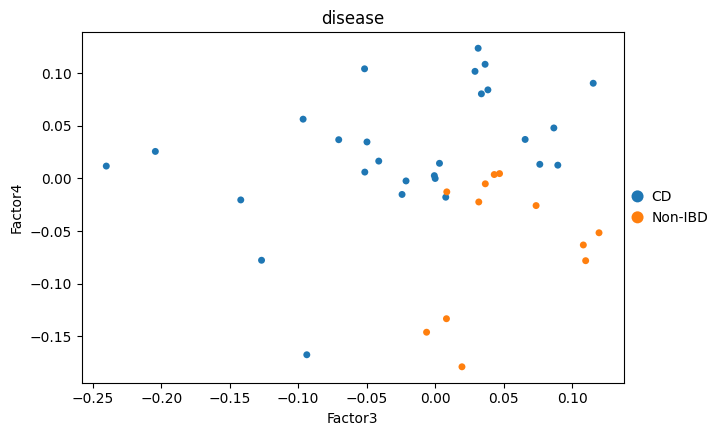

In [81]:
sc.pl.scatter(project_dat,
              x = "Factor3",
              y = "Factor4", 
              color  = "disease", 
              size =100)

In reality, we would like to test if our factor associated with disease ("Factor 4") is still able to separate Crohn's disease patients from controls

In [24]:
# Filter for only Factor4 associations
disease_accs = mina.down.get_associations(project_dat, 
                           test_variable = "disease",
                           test_type="categorical")

disease_accs[disease_accs["feature"] == "Factor4"]

,feature,statistic,p_value,adj_p_value
3,Factor4,15.863546,0.000307,0.001533


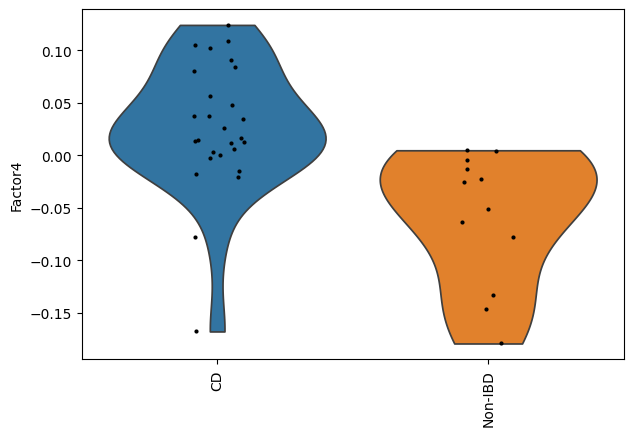

In [25]:
sc.pl.violin(project_dat, 
             ["Factor4"], 
             groupby="disease", rotation=90,size = 3)

Similarly to the previous tutorial, higher values of Factor 4 are associated with disease.

---

## Summary

In this vignette, we applied semi-supervised multicellular factor analysis to model coordinated sample-level variation across epithelial cell types in inflammatory bowel disease.

The key difference from the introductory tutorial is the inclusion of a guided factor associated with `biosample_enriched_fraction`, capturing variation between lamina propria–enriched and epithelial-enriched biopsies. This allows the remaining latent factors to more clearly represent disease-associated variation.

We also demonstrated how multicellular programs learned from one dataset can be used as a reference to project additional datasets with a similar biological context.

The next vignette introduces joint modeling of multiple datasets using `MOFA+`, an alternative to projection.